如果使用计算屈服强度预测屈服强度，其R2非常低

In [6]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
df=pd.read_excel('train_set.xlsx',index_col=0)
y=df['屈服强度']
y_pred=df['Calculated Yield Strength']
r2 = r2_score(y,y_pred)
mae = mean_absolute_error(y,y_pred)
mape = mean_absolute_percentage_error(y,y_pred)
print('r2:',r2,'\n','mae=',mae,'mape=',mape)

r2: 0.054916898715671625 
 mae= 62.7995787501043 mape= 0.332490411602962


在测试集的100个样本上进行投票，选择最合适的模型，这里选择了最佳的前五个单独模型参与投票，分别赋予不同的权重，最佳结果为weight8，rf0.3，xgb0.7

In [2]:
# 预测屈服强度
import joblib
import numpy as np
import pandas as pd
import os
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import StratifiedKFold,train_test_split,cross_validate,cross_val_score,KFold
score_path='predict_performanceFULL.xlsx'

if os.path.exists(score_path):
    print(f"The file '{score_path}' exists.")
else:
    print(f"The file '{score_path}' does not exist.")
    df = pd.DataFrame(columns=['Model', 'R^2', 'MAPE', 'MAE'])
    df.to_excel(score_path, index=False)


df = pd.read_excel('test_set.xlsx',index_col=0)
# df = df[df['计算晶界'] != 0].reset_index(drop=True)

X_test = df.drop(columns=['Precipitate Distribution',
       '屈服强度', '抗拉强度 (UTS)', '追踪编号'])  # 特征: 最后四列之前的所有列
y_test = df.iloc[:, -3]  # 目标: 倒数第四列
# print(y)


# weights = {'rf_best.pkl': 0.35, 'xgboost_best.pkl': 0.35, 'adaboost_best_new.pkl': 0.2, 'svm_rbf_best_new.pkl': 0.1}
# 绝对路径列表
# 更新模型路径列表
# model_paths = [
#     'models/gboost/gboost_best_new.pkl', 'models/rf/rf_best_new.pkl', 'models/xgboost/xgboost_best_new.pkl',
#     'models/knn/knn_best_new.pkl', 'models/adaboost/adaboost_best_new.pkl'
# 
# ]

# 更新权重字典
# weights1 = {'gboost_best_new.pkl': 1, 'rf_best_new.pkl': 0, 'xgboost_best_new.pkl': 0, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
# weights2 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 1, 'xgboost_best_new.pkl': 0, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
# weights3 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0, 'xgboost_best_new.pkl': 1, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
# weights4 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0, 'xgboost_best_new.pkl': 0, 'knn_best_new.pkl': 1, 'adaboost_best_new.pkl': 0, }
# weights5 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0, 'xgboost_best_new.pkl': 0, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 1, }
# weights6 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.5, 'xgboost_best_new.pkl': 0.5, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, 'dt_best_new.pkl': 0, 'ridge_best_new.pkl': 0, 'elas0.ticNet_best_new.pkl': 0, 'lasso_best_new.pkl': 0, 'svm_linear_best_new.pkl': 0, 'svm_rbf_best_new.pkl': 0}
# weights7 = {'gboost_best_new.pkl': 0.2, 'rf_best_new.pkl': 0.2, 'xgboost_best_new.pkl': 0.4, 'knn_best_new.pkl': 0.2, 'adaboost_best_new.pkl': 0, }
# weights8 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.3, 'xgboost_best_new.pkl': 0.7, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
# weights9 = {'gboost_best_new.pkl': 0.3, 'rf_best_new.pkl': 0.3, 'xgboost_best_new.pkl': 0.4, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
# weights10 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.3, 'xgboost_best_new.pkl': 0.5, 'knn_best_new.pkl': 0.2, 'adaboost_best_new.pkl': 0, }
# weights11 = {'gboost_best_new.pkl': 0.25, 'rf_best_new.pkl': 0.25, 'xgboost_best_new.pkl': 0.25, 'knn_best_new.pkl': 0.25, 'adaboost_best_new.pkl': 0.25, }
# weight_ls=[weights1,weights2,weights3,weights4,weights5,weights6,weights7,weights8,weights9,weights10,weights11]

model_paths = [
    'models/gboost/gboost_best_new.pkl', 'models/rf/rf_best_new.pkl', 'models/xgboost/xgboost_optimization2.pkl',
    'models/knn/knn_best_new.pkl', 'models/adaboost/adaboost_best_new.pkl'

]

# 更新权重字典
weights1 = {'gboost_best_new.pkl': 1, 'rf_best_new.pkl': 0, 'xgboost_optimization2.pkl': 0, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights2 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 1, 'xgboost_optimization2.pkl': 0, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights3 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0, 'xgboost_optimization2.pkl': 1, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights4 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0, 'xgboost_optimization2.pkl': 0, 'knn_best_new.pkl': 1, 'adaboost_best_new.pkl': 0, }
weights5 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0, 'xgboost_optimization2.pkl': 0, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 1, }
weights6 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.5, 'xgboost_optimization2.pkl': 0.5, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, 'dt_best_new.pkl': 0, 'ridge_best_new.pkl': 0, 'elas0.ticNet_best_new.pkl': 0, 'lasso_best_new.pkl': 0, 'svm_linear_best_new.pkl': 0, 'svm_rbf_best_new.pkl': 0}
weights7 = {'gboost_best_new.pkl': 0.5, 'rf_best_new.pkl': 0.5, 'xgboost_optimization2.pkl': 0 ,'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights8 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.3, 'xgboost_optimization2.pkl': 0.7, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights9 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.7, 'xgboost_optimization2.pkl': 0.3, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights10 = {'gboost_best_new.pkl': 0.7, 'rf_best_new.pkl': 0, 'xgboost_optimization2.pkl': 0.3, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights11 = {'gboost_best_new.pkl': 0, 'rf_best_new.pkl': 0.3, 'xgboost_optimization2.pkl': 0.5, 'knn_best_new.pkl': 0.2, 'adaboost_best_new.pkl': 0, }
weights12 = {'gboost_best_new.pkl': 0.5, 'rf_best_new.pkl': 0.3, 'xgboost_optimization2.pkl': 0.2, 'knn_best_new.pkl': 0, 'adaboost_best_new.pkl': 0, }
weights13 = {'gboost_best_new.pkl': 0.25, 'rf_best_new.pkl': 0.25, 'xgboost_optimization2.pkl': 0.25, 'knn_best_new.pkl': 0.25, 'adaboost_best_new.pkl': 0, }
weights14 = {'gboost_best_new.pkl': 0.2, 'rf_best_new.pkl': 0.2, 'xgboost_optimization2.pkl': 0.2, 'knn_best_new.pkl': 0.2, 'adaboost_best_new.pkl': 0.2 }
weight_ls=[weights1,weights2,weights3,weights4,weights5,weights6,weights7,weights8,weights9,weights10,weights11,weights12,weights13,weights14]
t=0
df = pd.read_excel(score_path)
# 添加新数据的示例
new_row = pd.Series(dtype='object')
df_new_row = pd.DataFrame([new_row])
df = pd.concat([df,df_new_row],ignore_index = True)
for weights in weight_ls:
    t=t+1
    print(f'--------第{t}种投票结果如下--------')
    # 初始化加权预测结果的存储数组
    weighted_preds = np.zeros(y_test.shape)

    for model_path in model_paths:
        # print('model_path:',model_path)
        # 获取模型文件的简单名称，如'A.pkl'
        model_name = model_path.split('/')[-1]
        # 加载模型
        model = joblib.load(model_path)
        # 进行预测
        pred = model.predict(X_test)
        # 根据模型名称获取其权重并计算加权预测结果
        weighted_preds += weights[model_name] * pred
    # print('weighted_preds:\n',weighted_preds)
    # 计算平均误差
    err = abs(y_test - weighted_preds)

    print('误差列表如下：')
    # for i in err.index:
    #     if err[i]<50:
    #         print(f'{err[i]:.4},origin={y_test[i]}')
    mae=np.mean(err)
    print('平均误差：',mae )

    r2 = r2_score(y_test, weighted_preds)
    print('R^2精度：',r2)

    mape=mean_absolute_percentage_error(y_test,weighted_preds)
    print('平均绝对百分误差：',mape*100,'%')

    new_data = {'Model': f'{t}', 'R^2': r2, 'MAPE': mape * 100, 'MAE': mae}
    # 将新数据添加到数据框中
    
    df_new_data = pd.DataFrame([new_data])
    df = pd.concat([df,df_new_data],ignore_index = True)
    # 保存数据框到Excel表格
    df.to_excel(score_path, index=False)

The file 'predict_performanceFULL.xlsx' exists.
--------第1种投票结果如下--------
误差列表如下：
平均误差： 34.36167108147256
R^2精度： 0.774562376489532
平均绝对百分误差： 22.441790554502077 %
--------第2种投票结果如下--------


D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingRegressor from version 1.4.2 when using version 1.5.1. This migh

误差列表如下：
平均误差： 34.35537945132645
R^2精度： 0.7837708256981452
平均绝对百分误差： 21.745863834692106 %
--------第3种投票结果如下--------
误差列表如下：
平均误差： 33.528802069091796
R^2精度： 0.7380361922203176
平均绝对百分误差： 21.24856903700906 %
--------第4种投票结果如下--------


D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingRegressor from version 1.4.2 when using version 1.5.1. This migh

误差列表如下：
平均误差： 40.406451223958804
R^2精度： 0.7219524305668675
平均绝对百分误差： 26.27612720904545 %
--------第5种投票结果如下--------
误差列表如下：
平均误差： 46.24927732926624
R^2精度： 0.6850279444238225
平均绝对百分误差： 34.17321543555377 %


...

D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator AdaBoostRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.4.2 when using version 1.5.1. This might lead t

--------第12种投票结果如下--------
误差列表如下：
平均误差： 33.14478143307556
R^2精度： 0.7854057681235179
平均绝对百分误差： 21.328803576788353 %
--------第13种投票结果如下--------


D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingRegressor from version 1.4.2 when using version 1.5.1. This migh

误差列表如下：
平均误差： 33.89495080987253
R^2精度： 0.7865181319033809
平均绝对百分误差： 21.97437307914878 %
--------第14种投票结果如下--------
误差列表如下：
平均误差： 35.39738390886734
R^2精度： 0.7825921496806408
平均绝对百分误差： 23.85469804993357 %


D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Anaconda\envs\torch24\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator AdaBoostRegressor from version 1.4.2 when using version 1.5.1. This might l

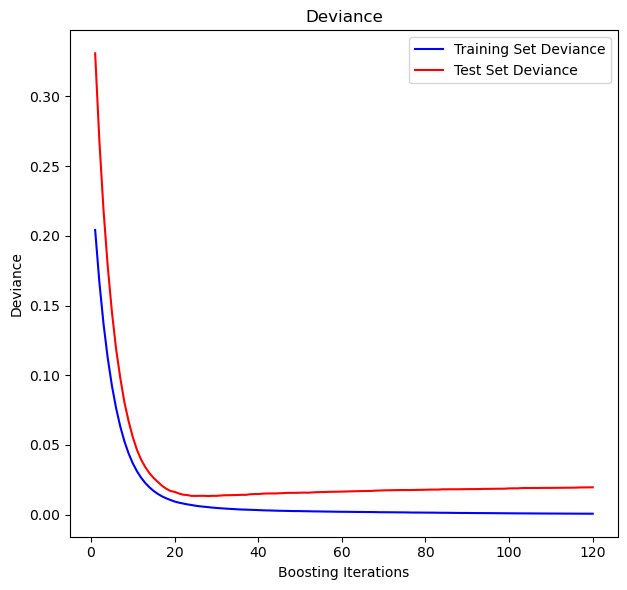

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 创建一些示例数据
X = np.random.rand(100, 1) * 2 - 1  # 100个随机点
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])  # 对应的正弦值加上一些噪声

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建和拟合模型
params = {
    'n_estimators': 120,
    'max_depth': 3,
    'min_samples_split': 2,
    'learning_rate': 0.1,
    'loss': 'squared_error'  # 使用新的损失参数
}
model = GradientBoostingRegressor(**params)
model.fit(X_train, y_train)

# 评估模型在每一步的表现
test_score = np.zeros((params['n_estimators'],), dtype=np.float64)
for i, y_pred in enumerate(model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

# 绘制迭代过程中的测试损失
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Deviance')
plt.plot(np.arange(params['n_estimators']) + 1, model.train_score_, 'b-', label='Training Set Deviance')
plt.plot(np.arange(params['n_estimators']) + 1, test_score, 'r-', label='Test Set Deviance')
plt.legend(loc='upper right')
plt.xlabel('Boosting Iterations')
plt.ylabel('Deviance')

# 显示图形
plt.tight_layout()
plt.show()
